# 8BWT as a 2.5D graph with `rnaglib`

Instead of parsing the NDB annotation file ourselves, this notebook uses
[`rnaglib`](https://rnaglib.org) to build and visualize the graph for **8BWT** directly.

`rnaglib.dataset.rna_from_pdbid("8bwt")`:
1. downloads the coordinate mmCIF for 8BWT from the PDB,
2. runs **FR3D** to annotate base pairs (Leontis–Westhof families), and
3. returns a **2.5D graph** — a `networkx.MultiDiGraph` where
   - **nodes** = nucleotides (`nt_code`, `xyz_P` phosphate coords, `is_modified`, binding context),
   - **edges** = backbone (`B53`/`B35`) **+** base pairs labelled by LW family (`cWW`, `tWS`, …).

Notes:
- FR3D must be installed (`pip install git+https://github.com/cgoliver/fr3d-python.git`); it is already in this pixi env.
- rnaglib uses only **model 1** for coordinates but FR3D annotates every model, so multi-model
  base pairs collapse onto the 26 chain-A nodes as **parallel edges** — the *unique* pair set is
  therefore the union over all 10 models.
- The first run downloads + annotates (~1 min) and FR3D is very chatty, so we silence its stdout.

In [1]:
import contextlib

import matplotlib.pyplot as plt

# rna_from_pdbid downloads + runs FR3D; redirect its noisy stdout to a log file.
with open("fr3d_build.log", "w") as _f, contextlib.redirect_stdout(_f):
    from rnaglib.dataset import rna_from_pdbid
    from rnaglib.drawing import rna_draw
    out = rna_from_pdbid("8bwt")

G = out["rna"]
print(type(G).__name__, "| nodes:", G.number_of_nodes(), "| edges:", G.number_of_edges())

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MultiDiGraph | nodes: 26 | edges: 530


/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/forgi/threedee/utilities/pdb.py:661: UserWarning: Multiple models in file. Using only the first model
  warnings.warn("Multiple models in file. Using only the first model")


## 1. Inspect the graph

In [2]:
from collections import Counter

n0 = list(G.nodes)[0]
print("example node :", n0)
print("node attrs   :", sorted(G.nodes[n0].keys()))
print("nt_code / P  :", G.nodes[n0].get("nt_code"), G.nodes[n0].get("xyz_P"))

# edges only carry the LW label; backbone is B53/B35
lw = Counter(d.get("LW") for *_ , d in G.edges(data=True))
print("\nLW edge counts (directed, with per-model parallels):", dict(lw))

# collapse parallels -> unique undirected base pairs
uniq = {}
for a, b, d in G.edges(data=True):
    if d["LW"] not in ("B53", "B35"):
        uniq[frozenset((a, b))] = d["LW"]
print("unique base pairs:", len(uniq), "->", dict(Counter(uniq.values())))

example node : 8bwt.A.2
node attrs   : ['binding_ion_4.0A', 'binding_ion_6.0A', 'binding_ion_8.0A', 'binding_small-molecule-4.0A', 'binding_small-molecule-6.0A', 'binding_small-molecule-8.0A', 'chain_id', 'is_modified', 'nt', 'nt_code', 'nt_full', 'protein_binding', 'protein_content', 'protein_content_4.0', 'protein_content_6.0', 'protein_content_8.0', 'xyz_P']
nt_code / P  : G [2.382999897003174, 0.11900000274181366, 5.886000156402588]

LW edge counts (directed, with per-model parallels): {'B53': 25, 'B35': 25, 'cWW': 440, 'tSW': 20, 'tWS': 20}
unique base pairs: 12 -> {'cWW': 11, 'tWS': 1}


## 2. Visualize — rnaglib's native 2.5D drawing

`rna_draw` lays the nucleotides on a circle and draws base pairs with **Leontis–Westhof glyphs**
(e.g. ⊕ = cis Watson–Crick). Black arrows are the backbone; node colours encode the nucleotide.

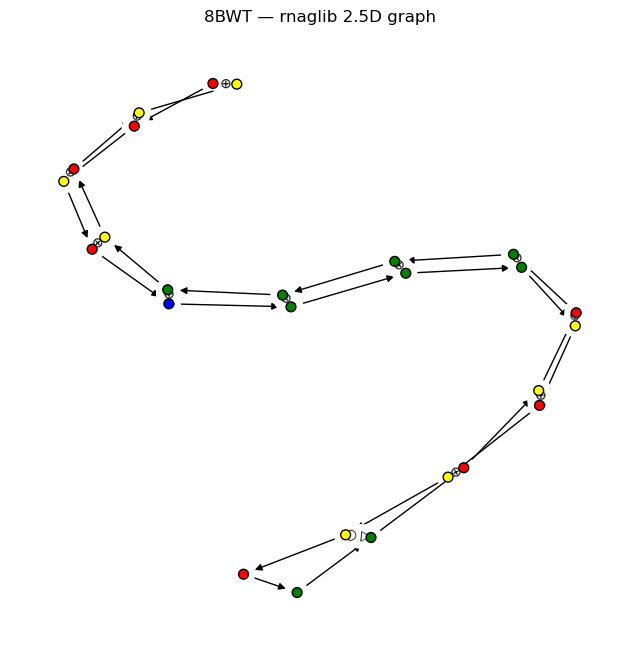

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
rna_draw(G, title="8BWT — rnaglib 2.5D graph", ax=ax, layout="spring",
         node_ids=True)
plt.show()

## 3. Visualize — secondary-structure arc diagram

The circular 2.5D view is the rnaglib standard, but the hairpin is clearer as an **arc diagram**:
sequence on a line (5'→3'), base pairs as arcs above. Nested arcs ⇒ the stem; the gap ⇒ the loop.
Backbone edges are dropped here; non-cWW pairs are dashed.

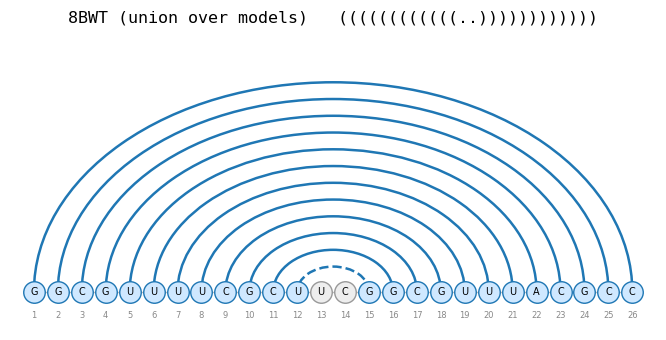

In [4]:
from matplotlib.patches import Arc


def position(node):
    return int(node.rsplit(".", 1)[1])  # node id like '8bwt.A.7'


nodes = sorted(G.nodes, key=position)
xpos = {n: k for k, n in enumerate(nodes)}
paired = {n for pair in uniq for n in pair}

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot([0, len(nodes) - 1], [0, 0], color="#bbbbbb", lw=1, zorder=0)
db = ["."] * len(nodes)
for n in nodes:
    x = xpos[n]
    is_paired = n in paired
    ax.scatter([x], [0], s=240, zorder=3,
               color="#cfe8ff" if is_paired else "#eeeeee",
               edgecolors="#1f77b4" if is_paired else "#999999")
    ax.text(x, 0, G.nodes[n].get("nt_code", "?"), ha="center", va="center", fontsize=7, zorder=4)
    ax.text(x, -1.0, str(position(n)), ha="center", va="center", fontsize=6, color="#888")
for pair, fam in uniq.items():
    a, b = sorted(xpos[n] for n in pair)
    db[a], db[b] = "(", ")"
    w = b - a
    ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.7, theta1=0, theta2=180,
                     color="#1f77b4", lw=1.8,
                     linestyle="-" if fam == "cWW" else "--", zorder=2))
ax.set_xlim(-1, len(nodes)); ax.set_ylim(-1.6, len(nodes) * 0.42)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("8BWT (union over models)   " + "".join(db), fontfamily="monospace")
plt.tight_layout(); plt.show()

## 4. Export the rnaglib graph to PyTorch Geometric

rnaglib's own `GraphRepresentation(framework="pyg")` is driven by a `FeaturesComputer`
(which has a bug in 3.4.x for the no-target case), so here is a direct, dependable
`networkx → PyG` conversion: one-hot `nt_code` nodes and LW-typed edges.

In [5]:
import torch
from torch_geometric.data import Data

NT = ["A", "C", "G", "U"]
idx = {n: i for i, n in enumerate(nodes)}

x = torch.zeros(len(nodes), len(NT))
for n in nodes:
    code = G.nodes[n].get("nt_code", "?")
    if code in NT:
        x[idx[n], NT.index(code)] = 1.0

lw_types = sorted({d["LW"] for *_ , d in G.edges(data=True)})
lw_id = {t: i for i, t in enumerate(lw_types)}
src, dst, etype = [], [], []
for u, v, d in G.edges(data=True):
    src.append(idx[u]); dst.append(idx[v]); etype.append(lw_id[d["LW"]])

data = Data(
    x=x,
    edge_index=torch.tensor([src, dst], dtype=torch.long),
    edge_type=torch.tensor(etype, dtype=torch.long),
)
data.nt_vocab = NT
data.lw_types = lw_types
data.node_ids = nodes
print(data)
print("nt_vocab :", NT)
print("lw_types :", lw_types)

Data(x=[26, 4], edge_index=[2, 530], edge_type=[530], nt_vocab=[4], lw_types=[5], node_ids=[26])
nt_vocab : ['A', 'C', 'G', 'U']
lw_types : ['B35', 'B53', 'cWW', 'tSW', 'tWS']
